# Relevance Classification — Direct LLM Approach (`R2-A`)

This notebook is self-contained: the relevance extraction model, relevance prompt, and GT export logic all live here. The only source-side change needed for this workflow is that `prompt_eval.run_eval(...)` now accepts notebook-defined Pydantic models instead of being hard-wired to the Fuster feature classes.

In [10]:
import json
import os
import sys
import warnings
from pathlib import Path
from typing import Literal, Optional

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pydantic import BaseModel, Field
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

warnings.filterwarnings("ignore")

from llm_metadata.groundtruth_eval import EvaluationConfig, FieldEvalStrategy
from llm_metadata.prompt_eval import run_eval
from llm_metadata.prompts.abstract import TASK_INSTRUCTIONS
from llm_metadata.prompts.common import (
    MODULATOR_FIELDS,
    OUTPUT_FORMAT,
    PERSONA,
    PHILOSOPHY,
    SCOPING,
    VOCABULARY,
    build_prompt,
)
from llm_metadata.schemas.data_paper import DataPaperManifest, RunArtifact
from llm_metadata.schemas.fuster_features import DatasetFeaturesExtraction


## Local Schema And Prompt

The prompt stays in the notebook so the experiment is portable and explicit. We keep the abstract extraction instructions here, then append a notebook-specific relevance scoring block.

In [11]:
RELEVANCE_BLOCK = """## RELEVANCE SCORING

After extracting all features, assign an overall relevance score for Quebec biodiversity
monitoring using the same mechanistic target used in WU-R1 (`MC_relevance_modifiers`).
Prefer conservative scores when evidence is incomplete.

Main Classifiers (majority vote):
- Data type: H=abundance, density, EBV genetic analysis; M=distribution, presence-absence; L=presence-only, relative abundance, species richness, non-EBV genetic analysis; X=no species or biodiversity data
- Temporal extent: H=12+ years, M=3-11 years, L=1-2 years, X=not stated
- Spatial extent: H=>15000 km², M=5000-15000 km², L=<5000 km², X=not stated

If there is no majority:
- Special case: if data type is H and temporal or spatial is X, return L
- Otherwise return the lower of data type and the better of temporal/spatial

Modulators:
- Upgrade by one level if any of these are explicitly supported: multispecies (>10 species), threatened_species, new_species_science, new_species_region, bias_north_south
- Set has_dataset=False and relevance="X" if no primary dataset is described.
"""


class DatasetFeaturesWithRelevance(DatasetFeaturesExtraction):
    has_dataset: bool = Field(
        description="True if the record describes an actual dataset produced or curated by the authors."
    )
    relevance: Literal["H", "M", "L", "X"] = Field(
        description=(
            "Overall dataset relevance for Quebec biodiversity monitoring. "
            "H = high, M = moderate, L = low, X = non-relevant or no dataset."
        )
    )
    relevance_reasoning: str = Field(
        description="One to three sentences explaining the relevance verdict from the extracted evidence."
    )


class DatasetFeaturesWithRelevanceGT(BaseModel):
    relevance: Literal["H", "M", "L", "X"]
    human_relevance: Optional[Literal["H", "M", "L", "X"]] = None


SYSTEM_MESSAGE_WITH_RELEVANCE = build_prompt(
    PERSONA,
    TASK_INSTRUCTIONS,
    PHILOSOPHY,
    SCOPING,
    VOCABULARY,
    MODULATOR_FIELDS,
    OUTPUT_FORMAT,
    RELEVANCE_BLOCK,
)

EVAL_CONFIG = EvaluationConfig(
    field_strategies={
        "relevance": FieldEvalStrategy(match="exact"),
    }
)

print("Prompt length:", len(SYSTEM_MESSAGE_WITH_RELEVANCE))
print("Prediction schema:", DatasetFeaturesWithRelevance.__name__)
print("GT schema:", DatasetFeaturesWithRelevanceGT.__name__)
print("Evaluated fields:", sorted(EVAL_CONFIG.field_strategies.keys()))


Prompt length: 10774
Prediction schema: DatasetFeaturesWithRelevance
GT schema: DatasetFeaturesWithRelevanceGT
Evaluated fields: ['relevance']


## Data Loading And GT Manifest Export

The GT manifest is built directly in the notebook so it stays aligned with the local prediction model and the `MC_relevance_modifiers` target.

In [12]:
LABEL_ORDER = ["H", "M", "L", "X"]
GT_MANIFEST_PATH = PROJECT_ROOT / "data" / "gt" / "relevance_llm_direct_dev_subset_gt.json"

manifest = DataPaperManifest.load_csv(PROJECT_ROOT / "data" / "manifests" / "dev_subset_data_paper.csv")
manifest_df = pd.DataFrame([record.model_dump(mode="python") for record in manifest.records])

raw_df = pd.read_excel(PROJECT_ROOT / "data" / "dataset_092624.xlsx")
subset_ids = {record.gt_record_id for record in manifest.records}
df = raw_df[raw_df["id"].isin(subset_ids)].copy()
df["human_relevance"] = (
    df["dataset_relevance"]
    .replace({"No dataset": "X", " X": "X"})
    .fillna("")
    .astype(str)
    .str.strip()
)
df["relevance"] = df["MC_relevance_modifiers"].fillna("").astype(str).str.strip()
df = df.merge(
    manifest_df[["gt_record_id", "abstract", "title"]],
    left_on="id",
    right_on="gt_record_id",
    how="left",
    suffixes=("", "_manifest"),
)
df["input_text"] = df["abstract"].fillna(df.get("full_text", ""))
eval_df = df[df["relevance"].isin(LABEL_ORDER)].copy()

gt_records = []
for _, row in eval_df.iterrows():
    gt_records.append(
        {
            "gt_record_id": int(row["id"]),
            "relevance": row["relevance"],
            "human_relevance": row["human_relevance"] if row["human_relevance"] in LABEL_ORDER else None,
        }
    )

GT_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
GT_MANIFEST_PATH.write_text(json.dumps(gt_records, indent=2), encoding="utf-8")

print(f"Evaluation records: {len(eval_df)}")
print()
print("Primary target distribution (MC_relevance_modifiers):")
print(eval_df["relevance"].value_counts())
print()
print("Diagnostic human-label distribution (dataset_relevance collapsed):")
print(eval_df["human_relevance"].value_counts())
print()
print(f"GT manifest written to: {GT_MANIFEST_PATH}")


Evaluation records: 30

Primary target distribution (MC_relevance_modifiers):
relevance
M    12
H    10
L     8
Name: count, dtype: int64

Diagnostic human-label distribution (dataset_relevance collapsed):
human_relevance
M    12
L    11
H     6
X     1
Name: count, dtype: int64

GT manifest written to: c:\Users\beav3503\dev\llm_metadata\data\gt\relevance_llm_direct_dev_subset_gt.json


## Prompt Eval Run

This uses the latest `prompt_eval` Python API surface. The notebook does not manage its own cache and does not pass `skip_cache`; extraction reuses the cache behavior already exposed by `prompt_eval` and the underlying extraction helpers.

In [13]:
MODEL = "gpt-5-mini"
REASONING_EFFORT = "low"
RUN_ARTIFACT_PATH = PROJECT_ROOT / "artifacts" / "runs" / "relevance_llm_direct.json"
RUN_DESCRIPTION = (
    "R2-A direct LLM relevance classification from abstract / repository-description text "
    "via prompt_eval with a notebook-local relevance schema."
)

if os.getenv("OPENAI_API_KEY"):
    report = run_eval(
        mode="abstract",
        manifest=manifest.records,
        gt=gt_records,
        prompt=SYSTEM_MESSAGE_WITH_RELEVANCE,
        config=EVAL_CONFIG,
        model=MODEL,
        reasoning_effort=REASONING_EFFORT,
        description=RUN_DESCRIPTION,
        output_path=RUN_ARTIFACT_PATH,
        text_format=DatasetFeaturesWithRelevance,
        gt_model=DatasetFeaturesWithRelevanceGT,
        parallelism=10
    )
    artifact = getattr(report, "run_artifact", None)
    if artifact is None:
        artifact = RunArtifact.load_json(RUN_ARTIFACT_PATH)
    prediction_source = "prompt_eval_api_run"
else:
    if not RUN_ARTIFACT_PATH.exists():
        raise RuntimeError(
            "OPENAI_API_KEY is not set and no saved run artifact exists at "
            f"{RUN_ARTIFACT_PATH}"
        )
    artifact = RunArtifact.load_json(RUN_ARTIFACT_PATH)
    report = None
    prediction_source = "saved_run_artifact"

print(f"Prediction source: {prediction_source}")
print(f"Run artifact: {RUN_ARTIFACT_PATH}")
print(f"Successful records: {sum(record.status == 'success' for record in artifact.records)} / {len(artifact.records)}")
print(f"Total API cost: ${artifact.total_cost_usd:.4f}")
if report is not None and "relevance" in report.field_metrics:
    relevance_metrics = report.field_metrics["relevance"]
    print(
        "Prompt-eval relevance metrics:",
        {
            "precision": relevance_metrics.precision,
            "recall": relevance_metrics.recall,
            "f1": relevance_metrics.f1,
        },
    )


Prediction source: prompt_eval_api_run
Run artifact: c:\Users\beav3503\dev\llm_metadata\artifacts\runs\relevance_llm_direct.json
Successful records: 30 / 30
Total API cost: $0.2438
Prompt-eval relevance metrics: {'precision': 0.4, 'recall': 0.4, 'f1': 0.4000000000000001}


## Prediction Table

In [14]:
OUTPUT_PREDICTIONS_PATH = PROJECT_ROOT / "notebooks" / "results" / "relevance_llm_direct_predictions.csv"

prediction_rows = []
for record in artifact.records:
    parsed_output = None
    if record.status == "success" and record.output is not None:
        parsed_output = DatasetFeaturesWithRelevance.model_validate(record.output)
    prediction_rows.append(
        {
            "gt_record_id": record.gt_record_id,
            "pred_relevance": parsed_output.relevance if parsed_output else None,
            "has_dataset": parsed_output.has_dataset if parsed_output else None,
            "relevance_reasoning": parsed_output.relevance_reasoning if parsed_output else None,
            "data_type": parsed_output.data_type if parsed_output else None,
            "temp_range_i": parsed_output.temp_range_i if parsed_output else None,
            "temp_range_f": parsed_output.temp_range_f if parsed_output else None,
            "spatial_range_km2": parsed_output.spatial_range_km2 if parsed_output else None,
            "cost": (record.usage_cost or {}).get("total_cost"),
            "status": record.status,
            "error_message": record.error_message,
        }
    )

pred_df = pd.DataFrame(prediction_rows)
results_df = eval_df[["id", "title", "relevance", "human_relevance", "input_text"]].rename(
    columns={"id": "gt_record_id", "relevance": "gt_relevance"}
)
results_df = results_df.merge(pred_df, on="gt_record_id", how="left")
results_df["id"] = results_df["gt_record_id"]
results_df = results_df[results_df["pred_relevance"].notna()].copy()

OUTPUT_PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
results_df[
    [
        "id",
        "gt_relevance",
        "human_relevance",
        "pred_relevance",
        "has_dataset",
        "relevance_reasoning",
        "data_type",
        "temp_range_i",
        "temp_range_f",
        "spatial_range_km2",
        "cost",
        "status",
    ]
].to_csv(OUTPUT_PREDICTIONS_PATH, index=False)

print(f"Records with predictions: {len(results_df)}")
print()
print("Predicted relevance distribution:")
print(results_df["pred_relevance"].value_counts())
print()
print(f"Saved predictions: {OUTPUT_PREDICTIONS_PATH}")

results_df[
    [
        "id",
        "gt_relevance",
        "human_relevance",
        "pred_relevance",
        "has_dataset",
        "data_type",
        "temp_range_i",
        "temp_range_f",
    ]
].head(8)


Records with predictions: 30

Predicted relevance distribution:
pred_relevance
L    19
M    10
H     1
Name: count, dtype: int64

Saved predictions: c:\Users\beav3503\dev\llm_metadata\notebooks\results\relevance_llm_direct_predictions.csv


,id,gt_relevance,human_relevance,pred_relevance,has_dataset,data_type,temp_range_i,temp_range_f
0,5,M,M,M,True,[genetic_analysis],2006.0,2007.0
1,9,L,L,L,True,[abundance],NaN,NaN
2,11,M,M,L,True,[other],1999.0,2011.0
3,12,H,M,M,True,[presence-only],2004.0,2011.0
4,19,M,M,L,True,[genetic_analysis],2011.0,2014.0
5,24,H,H,L,True,[genetic_analysis],NaN,NaN
6,27,M,M,M,True,[genetic_analysis],2010.0,2014.0
7,29,H,H,L,True,[abundance],NaN,NaN


## Evaluation Metrics

Primary metrics are computed against `MC_relevance_modifiers`. A second diagnostic block compares the same predictions against `human_relevance`.

In [15]:
labels = ["H", "M", "L", "X"]


def binary_collapse(label: str) -> str:
    return "relevant" if label in {"H", "M"} else "not_relevant"


y_true = results_df["gt_relevance"]
y_pred = results_df["pred_relevance"]
present_labels = [label for label in labels if label in set(y_true)]

print("=== R2-A: Direct LLM From Abstract / Repository-Description Text vs Fuster MC+Modulators ===")
print()
print("Target labels present in dev subset:", present_labels)
print(classification_report(y_true, y_pred, labels=present_labels, zero_division=0))

y_true_bin = y_true.map(binary_collapse)
y_pred_bin = y_pred.map(binary_collapse)
binary_precision = precision_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
binary_recall = recall_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
binary_f1 = f1_score(y_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
macro_f1_present = f1_score(y_true, y_pred, labels=present_labels, average="macro", zero_division=0)
macro_f1_all = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)

print()
print("Binary (H+M = relevant vs L+X = not_relevant):")
print(f"  Precision: {binary_precision:.3f}  Recall: {binary_recall:.3f}  F1: {binary_f1:.3f}")
print()
print(f"Macro F1 over target-present labels: {macro_f1_present:.3f}")
print(f"Macro F1 over all four labels:       {macro_f1_all:.3f}")

human_true = results_df["human_relevance"]
human_present_labels = [label for label in labels if label in set(human_true)]
human_true_bin = human_true.map(binary_collapse)
human_binary_precision = precision_score(human_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
human_binary_recall = recall_score(human_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
human_binary_f1 = f1_score(human_true_bin, y_pred_bin, pos_label="relevant", zero_division=0)
human_macro_f1 = f1_score(
    human_true,
    y_pred,
    labels=human_present_labels,
    average="macro",
    zero_division=0,
)

print()
print("=== Diagnostic: Same Predictions vs Human dataset_relevance ===")
print()
print("Human-label target labels:", human_present_labels)
print(classification_report(human_true, y_pred, labels=human_present_labels, zero_division=0))
print()
print("Binary (H+M = relevant vs L+X = not_relevant):")
print(
    f"  Precision: {human_binary_precision:.3f}  Recall: {human_binary_recall:.3f}  F1: {human_binary_f1:.3f}"
)
print()
print(f"Macro F1 over human-label-present labels: {human_macro_f1:.3f}")


=== R2-A: Direct LLM From Abstract / Repository-Description Text vs Fuster MC+Modulators ===

Target labels present in dev subset: ['H', 'M', 'L']
              precision    recall  f1-score   support

           H       0.00      0.00      0.00        10
           M       0.60      0.50      0.55        12
           L       0.32      0.75      0.44         8

    accuracy                           0.40        30
   macro avg       0.31      0.42      0.33        30
weighted avg       0.32      0.40      0.34        30


Binary (H+M = relevant vs L+X = not_relevant):
  Precision: 0.818  Recall: 0.409  F1: 0.545

Macro F1 over target-present labels: 0.330
Macro F1 over all four labels:       0.247

=== Diagnostic: Same Predictions vs Human dataset_relevance ===

Human-label target labels: ['H', 'M', 'L', 'X']
              precision    recall  f1-score   support

           H       0.00      0.00      0.00         6
           M       0.60      0.50      0.55        12
           L   

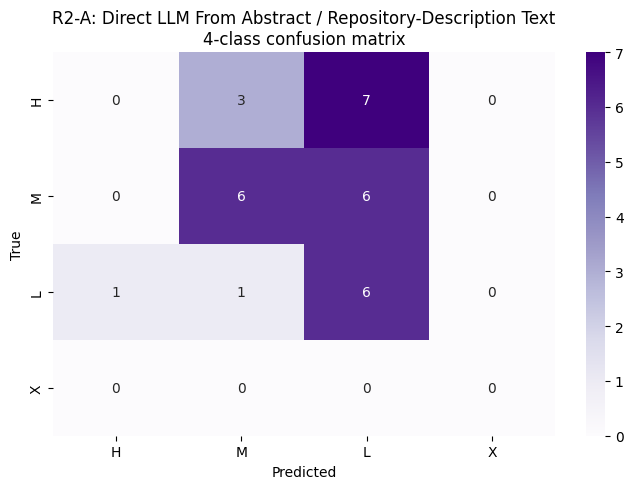

In [16]:
CONFUSION_PATH = PROJECT_ROOT / "notebooks" / "results" / "relevance_llm_direct_confusion.png"

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_true, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Purples", ax=ax)
ax.set_title("R2-A: Direct LLM From Abstract / Repository-Description Text" + chr(10) + "4-class confusion matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig(CONFUSION_PATH, dpi=150, bbox_inches="tight")
plt.show()


## Mismatch Analysis

Spot-check `relevance_reasoning` on mismatches.

In [17]:
mismatches = results_df[results_df["gt_relevance"] != results_df["pred_relevance"]].copy()
print(f"Mismatches: {len(mismatches)}/{len(results_df)} ({len(mismatches) / len(results_df):.1%})")

for _, row in mismatches.iterrows():
    print()
    print(f"--- Record {row['id']} ---")
    print(
        f"  GT mechanistic: {row['gt_relevance']}  |  "
        f"Human label: {row['human_relevance']}  |  Pred: {row['pred_relevance']}"
    )
    print(f"  has_dataset: {row['has_dataset']}")
    print(f"  data_type: {row['data_type']}")
    print(f"  temporal: {row['temp_range_i']} - {row['temp_range_f']}")
    print(f"  spatial: {row['spatial_range_km2']} km2")
    print(f"  Reasoning: {row['relevance_reasoning']}")


Mismatches: 18/30 (60.0%)

--- Record 11 ---
  GT mechanistic: M  |  Human label: M  |  Pred: L
  has_dataset: True
  data_type: ['other']
  temporal: 1999.0 - 2011.0
  spatial: nan km2
  Reasoning: Dataset is a primary telemetry-derived individual home-range and demographic dataset for woodland caribou in Québec spanning 1999–2011 (13 years), but the data type is not one of the high-priority EBV types (e.g., abundance or density) and the overall spatial extent is not reported. Therefore overall relevance for Quebec biodiversity monitoring is rated low.

--- Record 12 ---
  GT mechanistic: H  |  Human label: M  |  Pred: M
  has_dataset: True
  data_type: ['presence-only']
  temporal: 2004.0 - 2011.0
  spatial: nan km2
  Reasoning: Dataset comprises repeatability data on habitat selection for woodland caribou collected 2004–2011 (8 years, moderate temporal extent). The primary data are occurrence/used-location records for marked individuals (presence-only classification) so baseline dat

## Saved Summary

In [18]:
OUTPUT_SUMMARY_PATH = PROJECT_ROOT / "notebooks" / "results" / "relevance_llm_direct_summary.json"
COMPARISON_PATH = PROJECT_ROOT / "notebooks" / "results" / "relevance_comparison_summary.csv"

summary = {
    "method": "R2-A: Direct LLM from abstract/repository-description text vs Fuster MC+Modulators",
    "target": "MC_relevance_modifiers",
    "diagnostic_target": "dataset_relevance",
    "run_artifact": str(RUN_ARTIFACT_PATH),
    "gt_manifest": str(GT_MANIFEST_PATH),
    "model": MODEL,
    "reasoning_effort": REASONING_EFFORT,
    "records_total": int(len(eval_df)),
    "records_with_predictions": int(len(results_df)),
    "total_cost_usd": float(artifact.total_cost_usd),
    "macro_f1_present_labels": round(float(macro_f1_present), 3),
    "macro_f1_all_labels": round(float(macro_f1_all), 3),
    "binary_precision": round(float(binary_precision), 3),
    "binary_recall": round(float(binary_recall), 3),
    "binary_f1": round(float(binary_f1), 3),
    "human_macro_f1_present_labels": round(float(human_macro_f1), 3),
    "human_binary_precision": round(float(human_binary_precision), 3),
    "human_binary_recall": round(float(human_binary_recall), 3),
    "human_binary_f1": round(float(human_binary_f1), 3),
}

OUTPUT_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_SUMMARY_PATH.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(f"Saved summary: {OUTPUT_SUMMARY_PATH}")

comparison_rows = []
for path in [
    PROJECT_ROOT / "notebooks" / "results" / "relevance_mechanistic_summary.csv",
    PROJECT_ROOT / "notebooks" / "results" / "relevance_mechanistic_pdf_summary.csv",
]:
    if path.exists():
        comparison_rows.append(pd.read_csv(path))

direct_rows = [
    {
        "Method": "R2-A: Direct LLM from abstract/repository-description text vs Fuster MC+Modulators",
        "4-class macro F1": round(float(macro_f1_present), 3),
        "Binary F1 (relevant)": round(float(binary_f1), 3),
        "Binary P": round(float(binary_precision), 3),
        "Binary R": round(float(binary_recall), 3),
    }
]

direct_pdf_summary_path = PROJECT_ROOT / "notebooks" / "results" / "relevance_llm_direct_pdf_summary.json"
if direct_pdf_summary_path.exists():
    direct_pdf_summary = json.loads(direct_pdf_summary_path.read_text(encoding="utf-8"))
    direct_rows.append(
        {
            "Method": "R2-B: Direct LLM from PDF files vs Fuster MC+Modulators",
            "4-class macro F1": direct_pdf_summary["macro_f1_present_labels"],
            "Binary F1 (relevant)": direct_pdf_summary.get("binary_f1", direct_pdf_summary.get("binary_f1_relevant")),
            "Binary P": direct_pdf_summary["binary_precision"],
            "Binary R": direct_pdf_summary["binary_recall"],
        }
    )

comparison_rows.append(pd.DataFrame(direct_rows))
comparison_df = pd.concat(comparison_rows, ignore_index=True)
comparison_df = comparison_df.drop_duplicates(subset=["Method"], keep="last")
comparison_df.to_csv(COMPARISON_PATH, index=False)
print(f"Saved comparison: {COMPARISON_PATH}")
comparison_df


Saved summary: c:\Users\beav3503\dev\llm_metadata\notebooks\results\relevance_llm_direct_summary.json
Saved comparison: c:\Users\beav3503\dev\llm_metadata\notebooks\results\relevance_comparison_summary.csv


,Method,4-class macro F1,Binary F1 (relevant),Binary P,Binary R
1,R1-A: Rules on abstract/repository-description...,0.317,0.533,1.000,0.364
3,R0: Rules on GT features vs Fuster MC+Modulators,1.000,1.000,1.000,1.000
4,R1-B: Rules on PDF-derived LLM features vs Fus...,0.486,0.714,0.750,0.682
5,Diagnostic: Fuster MC+Modulators vs human data...,0.491,0.850,0.773,0.944
6,R2-A: Direct LLM from abstract/repository-desc...,0.330,0.545,0.818,0.409
7,R2-B: Direct LLM from PDF files vs Fuster MC+M...,0.553,0.851,0.800,0.909
